In [16]:
import pandas as pd

df_regression = pd.read_csv("labels_regression.csv")
df_survival = pd.read_csv("labels_unfiltered.csv")

Checking the impact of vahadane normalization on computing time

In [18]:
df_all = pd.read_csv("registry_anonymized.csv")


def get_len_vahadane(df):
    sum = 0
    for stain in ["HES", "PASM", "MSB", "Masson Goldner", "Masson Trichrom", "Lendrum"]:
        print(f"{stain}: {len(df[df['Stain'] == stain])}")
        sum += len(df[df["Stain"] == stain])
    return sum


a = get_len_vahadane(df_all)
df_filtered = df_all[~df_all["Diagnosis"].isna()]
b = get_len_vahadane(df_filtered)
print(f"Total: {a}, Filtered: {b}, Difference: {a-b}")

HES: 5522
PASM: 4557
MSB: 101
Masson Goldner: 6
Masson Trichrom: 2215
Lendrum: 91
HES: 4325
PASM: 2695
MSB: 75
Masson Goldner: 5
Masson Trichrom: 2105
Lendrum: 7
Total: 12492, Filtered: 9212, Difference: 3280


C:\Users\yvabel\AppData\Local\Temp\ipykernel_37120\3269592935.py:1: DtypeWarning: Columns (5,6,7,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv("registry_anonymized.csv")


Data analysis of labels

In [2]:
from itables import init_notebook_mode

init_notebook_mode(all_interactive=True)
df_regression_biopsy = df_regression.groupby("biopsy_number").first().reset_index()
df_survival_biopsy = df_survival.groupby("biopsy_number").first().reset_index()

In [3]:
df_regression_biopsy = df_regression_biopsy[df_regression_biopsy["source"] == "non_IgA"]
n_cases = len(df_regression_biopsy)
# Calculate Q1, Q3, and IQR
Q1 = df_regression_biopsy["eGFR"].quantile(0.25)
Q3 = df_regression_biopsy["eGFR"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_regression_biopsy = df_regression_biopsy[
    (df_regression_biopsy["eGFR"] >= lower_bound)
    & (df_regression_biopsy["eGFR"] <= upper_bound)
]

print(f"Removed {n_cases - len(df_regression_biopsy)} outliers")
print(f"Remaining rows: {len(df_regression_biopsy)}")

Removed 226 outliers
Remaining rows: 4650


count    4650.000000
mean       57.442289
std        40.057236
min         1.884298
25%        26.830555
50%        46.322123
75%        79.800568
max       179.612367
Name: eGFR, dtype: float64


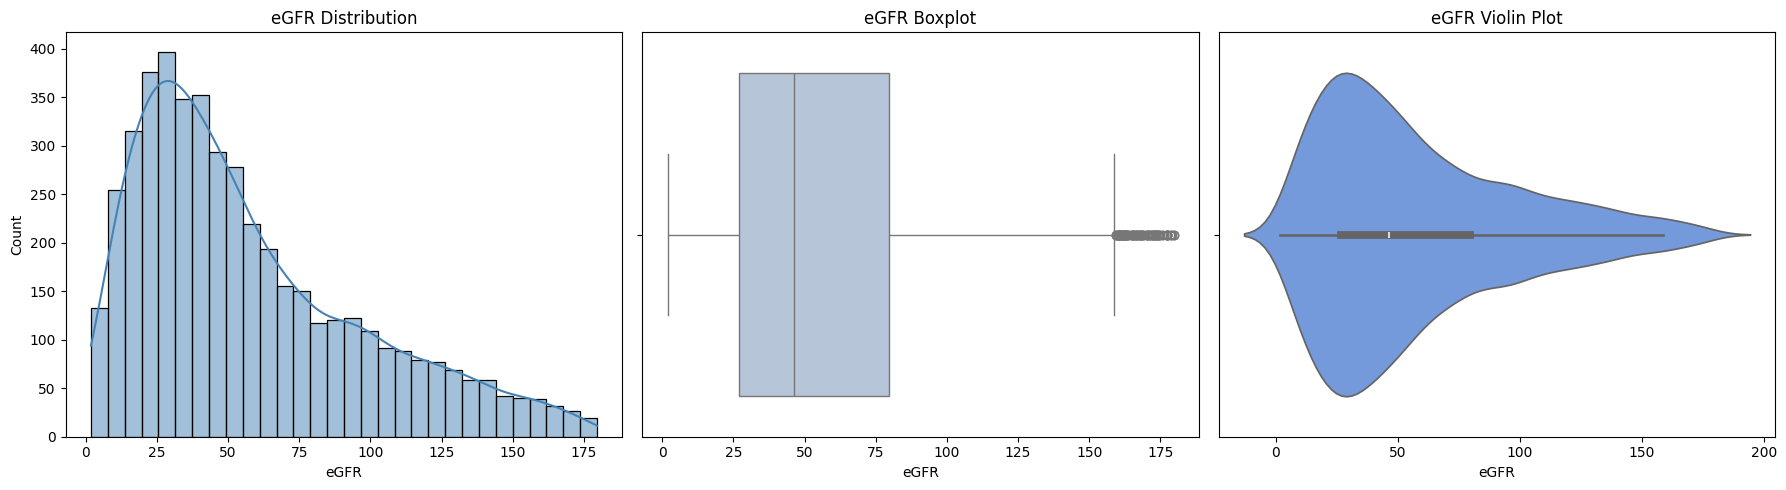

In [4]:
import seaborn as sns

import matplotlib.pyplot as plt

s = df_regression_biopsy["eGFR"]

# Basic summary statistics
print(s.describe())

# Plot: histogram with KDE, boxplot, and violin plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(s, bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("eGFR Distribution")
axes[0].set_xlabel("eGFR")
axes[0].set_ylabel("Count")

sns.boxplot(x=s, ax=axes[1], color="lightsteelblue")
axes[1].set_title("eGFR Boxplot")
axes[1].set_xlabel("eGFR")

sns.violinplot(x=s, ax=axes[2], color="cornflowerblue")
axes[2].set_title("eGFR Violin Plot")
axes[2].set_xlabel("eGFR")

plt.tight_layout()
plt.show()

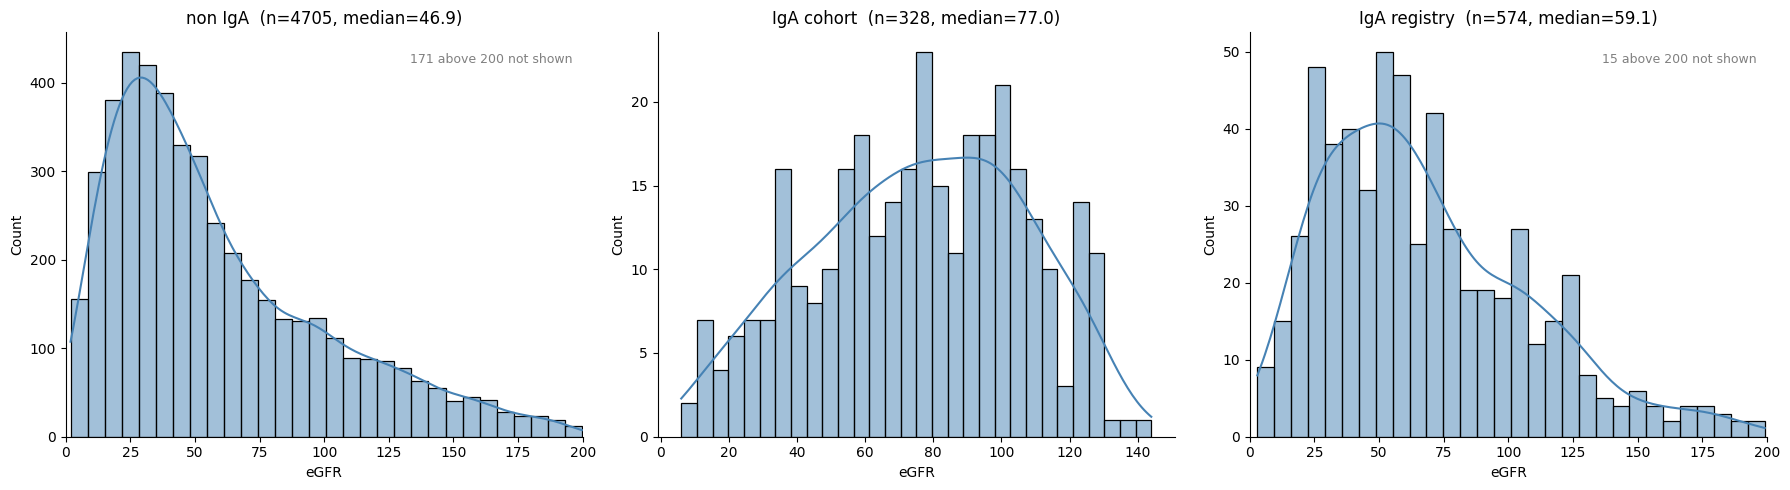

           count       mean         std       min        25%        50%  \
source                                                                    
IgA        328.0  75.756098   30.824674  6.000000  53.750000  77.000000   
non_IgA   4876.0  73.709332  301.737889  1.884298  27.619917  48.586765   
registry   589.0  72.486998   50.007466  2.903321  37.580044  60.208757   

                75%           max  
source                             
IgA       99.250000    144.000000  
non_IgA   88.450595  20411.099612  
registry  97.616476    436.479888  


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# biopsy-level frame, rebuilt because df_regression_biopsy was filtered to IgA above
df_biopsy = df_regression.groupby("biopsy_number").first().reset_index()

sources = ["non_IgA", "IgA", "registry"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, src in zip(axes, sources):
    s = df_biopsy.loc[df_biopsy["source"] == src, "eGFR"].dropna()
    # clip the long right tail (non_IgA reaches ~20000) so the bulk stays readable
    hi = s.quantile(0.99)
    n_clipped = (s > hi).sum()
    hi = 200
    n_clipped = (s > hi).sum()
    s = s[s <= hi]
    sns.histplot(s[s <= hi], bins=30, kde=True, ax=ax, color="steelblue")
    ax.set_title(f"{src}  (n={len(s)}, median={s.median():.1f})")
    ax.set_xlabel("eGFR")
    ax.set_ylabel("Count")
    source_labels = {
        "IgA": "IgA cohort",
        "registry": "IgA registry",
        "non_IgA": "non IgA",
    }
    ax.set_title(f"{source_labels[src]}  (n={len(s)}, median={s.median():.1f})")
    if n_clipped:
        ax.text(
            0.98,
            0.95,
            f"{n_clipped} above {hi:.0f} not shown",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            color="gray",
        )
        ax.set_xlim(0, 200)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

print(df_biopsy.groupby("source")["eGFR"].describe())